## Linear Regression Pipeline

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.pipeline import Pipeline

In [72]:
# read train and test dataset
train_set = pd.read_csv('train.csv')
test_set = pd.read_csv('test.csv')

outcome = train_set["BeatsPerMinute"]
features_train = train_set.drop(columns = ["id", "BeatsPerMinute"])
features_train = features_train[["RhythmScore","MoodScore","TrackDurationMs"]]

# train and validation split
features_train, features_val, outcome_train, outcome_val = train_test_split(features_train, outcome, test_size=0.1)
print(features_train.shape, features_val.shape, outcome_train.shape, outcome_val.shape)

# a light version of dataset for quick testing of model
features_train_light = features_train[:50000]
features_val_light = features_val[:5000]
outcome_train_light = outcome_train[:50000]
outcome_val_light = outcome_val[:5000]
print(features_train_light.shape, features_val_light.shape, outcome_train_light.shape, outcome_val_light.shape)

(471747, 3) (52417, 3) (471747,) (52417,)
(50000, 3) (5000, 3) (50000,) (5000,)


In [73]:
# try with a xgboost regressor
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', tree_method = "hist",colsample_bytree = 0.5, learning_rate = 0.05,
                max_depth = 5, alpha = 10, n_estimators = 800, device_type = 'cpu', subsample = 0.8)
xgb_model.fit(features_train, outcome_train)
prediction_xgb = xgb_model.predict(features_val)

c:\Users\tangx\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [19:01:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "device_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [76]:
# compute the metrics
mse_xgb = mean_squared_error(outcome_val, prediction_xgb)
mae_xgb = mean_absolute_error(outcome_val, prediction_xgb)
r2_xgb = r2_score(outcome_val, prediction_xgb)
print(f"The mean squared error is {mse_xgb}")
print(f"The mean absolute error is {mae_xgb}")
print(f"The r2 score is {r2_xgb}")

The mean squared error is 701.5627728789433
The mean absolute error is 21.188575279161995
The r2 score is -0.0004775803812115953


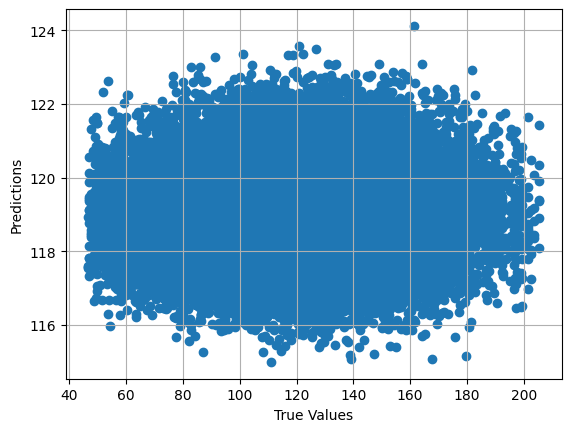

In [77]:
plt.scatter(outcome_val, prediction_xgb)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.grid()
plt.show()

In [78]:
# try with a histgradientboosting regressor
hgb_model = HistGradientBoostingRegressor(learning_rate = 0.05, max_iter = 800, max_bins = 255, max_depth = None)
hgb_model.fit(features_train, outcome_train)
prediction_hgb = hgb_model.predict(features_val)

In [79]:
# compute the metrics
mse_hgb = mean_squared_error(outcome_val, prediction_hgb)
mae_hgb = mean_absolute_error(outcome_val, prediction_hgb)
r2_hgb = r2_score(outcome_val, prediction_hgb)
print(f"The mean squared error is {mse_hgb}")
print(f"The mean absolute error is {mae_hgb}")
print(f"The r2 score is {r2_hgb}")

The mean squared error is 700.9517805677028
The mean absolute error is 21.183255970956463
The r2 score is 0.0003937373865099403


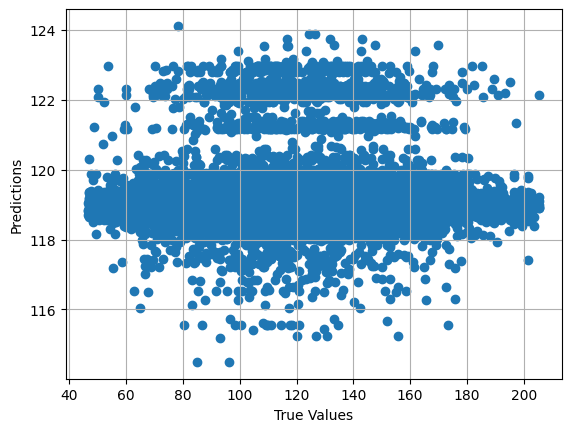

In [80]:
plt.scatter(outcome_val, prediction_hgb)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.grid()
plt.show()

In [81]:
# construct an ensemble pipeline with xgboost and histgradientboosting
pipe_xgb = Pipeline([("model", xgb_model)])
pipe_hgb = Pipeline([("model", hgb_model)])

pipe_xgb.fit(features_train, outcome_train)
pipe_hgb.fit(features_train, outcome_train)
pred_xgb = pipe_xgb.predict(features_val)
pred_hgb = pipe_hgb.predict(features_val)

weight = 0.4 # the weight can be tuned later
pred = weight * pred_xgb + (1 - weight) * pred_hgb

c:\Users\tangx\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [19:02:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "device_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [85]:
# compute the metrics
mse_ens = mean_squared_error(outcome_val, pred)
mae_ens = mean_absolute_error(outcome_val, pred)
r2_ens = r2_score(outcome_val, pred)
print(f"The mean squared error is {mse_ens}")
print(f"The mean absolute error is {mae_ens}")
print(f"The r2 score is {r2_ens}")

The mean squared error is 701.0226974922173
The mean absolute error is 21.182666282367045
The r2 score is 0.00029260489232818543


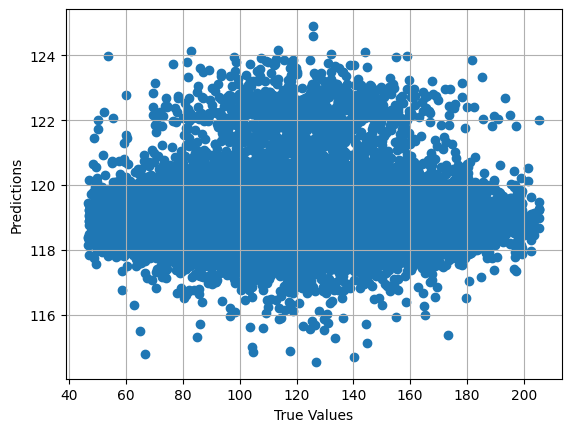

In [86]:
plt.scatter(outcome_val, pred)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.grid()
plt.show()

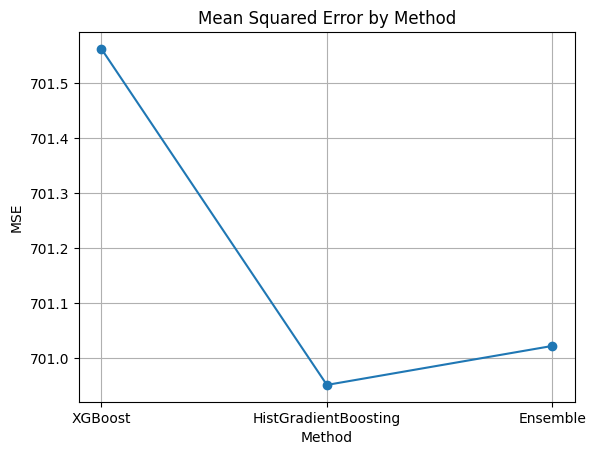

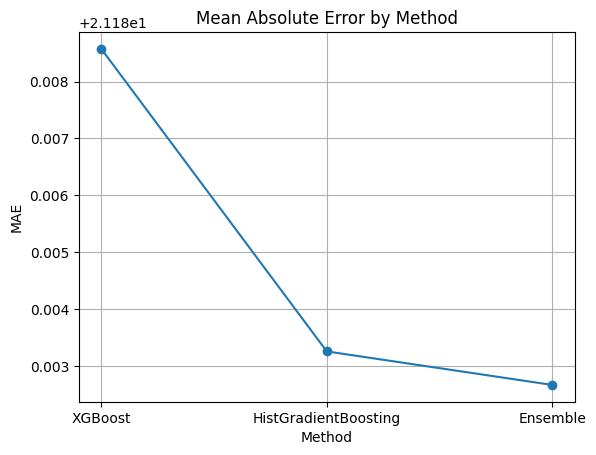

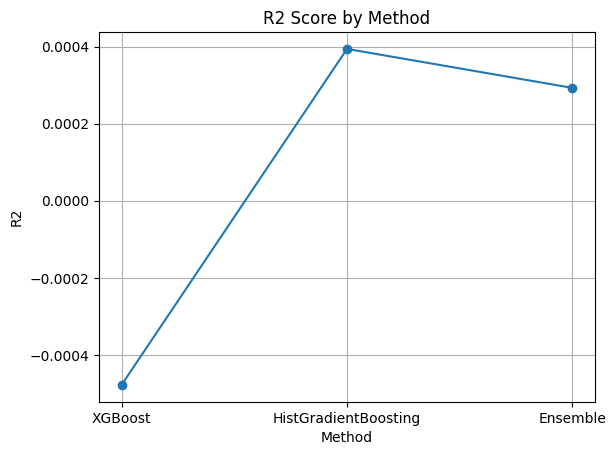

In [87]:
# compare the metrics of three approaches
method = ["XGBoost", "HistGradientBoosting", "Ensemble"]
mse_values = [mse_xgb, mse_hgb, mse_ens]
mae_values = [mae_xgb, mae_hgb, mae_ens]
r2_values = [r2_xgb, r2_hgb, r2_ens]

plt.plot(method, mse_values, marker='o', label='MSE')
plt.xlabel('Method')
plt.ylabel('MSE')
plt.title('Mean Squared Error by Method')
plt.grid()
plt.show()

plt.plot(method, mae_values, marker='o', label='MAE')
plt.xlabel('Method')
plt.ylabel('MAE')
plt.title('Mean Absolute Error by Method')
plt.grid()
plt.show()

plt.plot(method, r2_values, marker='o', label='R2')
plt.xlabel('Method')
plt.ylabel('R2')
plt.title('R2 Score by Method')
plt.grid()
plt.show()

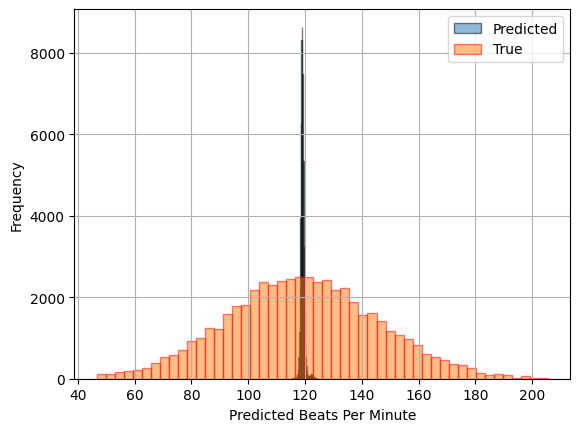

In [88]:
plt.hist(pred,bins = 50, edgecolor = "black", alpha = 0.5, label = "Predicted")
plt.hist(outcome_val,bins = 50, edgecolor = "red", alpha = 0.5, label= "True") 
plt.xlabel('Predicted Beats Per Minute')
plt.ylabel('Frequency')
plt.grid()
plt.legend()
plt.show()